In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print ("Done!")

Done!


In [2]:
from pathlib import Path

CALLS_FILE = Path(
    "data/raw/chisel-data/patientS0/calls/sectionE/calls.tsv.gz"
)

CLONES_FILE = Path(
    "data/raw/chisel-data/patientS0/clones/sectionE/mapping.tsv.gz"
)

print(CALLS_FILE.exists())
print(CLONES_FILE.exists())

True
True


In [3]:
calls = pd.read_csv(
    CALLS_FILE,
    sep = "\t",
    compression = "gzip"
)

clones = pd.read_csv(
    CLONES_FILE,
    sep = "\t",
    compression = "gzip"
)

In [4]:
print("Calls shape:", calls.shape)
print("Clones shape:", clones.shape)

Calls shape: (1182750, 12)
Clones shape: (2075, 3)


In [5]:
calls.head()

,#CHR,START,END,CELL,NORM_COUNT,COUNT,RDR,A_COUNT,B_COUNT,BAF,CLUSTER,CN_STATE
0,chr1,0,5000000,AAACCTGCACCAAAGG,2654972,547,0.801010,14,23,0.621622,3,1|2
1,chr1,0,5000000,AAACCTGCAGGACCAA,2654972,1340,0.822523,54,26,0.325000,3,2|1
2,chr1,0,5000000,AAACCTGGTAACTTCG,2654972,947,0.874127,43,17,0.283333,3,2|1
3,chr1,0,5000000,AAACCTGGTACCAGTT,2654972,1221,0.826999,47,25,0.347222,3,2|1
4,chr1,0,5000000,AAACCTGGTACCTAGT,2654972,656,1.200903,21,15,0.416667,3,1|1


In [6]:
calls.columns

Index(['#CHR', 'START', 'END', 'CELL', 'NORM_COUNT', 'COUNT', 'RDR', 'A_COUNT',
       'B_COUNT', 'BAF', 'CLUSTER', 'CN_STATE'],
      dtype='str')

In [7]:
clones.head()

,#CELL,CLUSTER,CLONE
0,AAACCTGCACCAAAGG,199,Clone199
1,AAACCTGCAGGACCAA,199,Clone199
2,AAACCTGGTAACTTCG,199,Clone199
3,AAACCTGGTACCAGTT,270,NaN
4,AAACCTGGTACCTAGT,5,Clone5


In [8]:
clones.columns

Index(['#CELL', 'CLUSTER', 'CLONE'], dtype='str')

In [9]:
calls.head(10)

,#CHR,START,END,CELL,NORM_COUNT,COUNT,RDR,A_COUNT,B_COUNT,BAF,CLUSTER,CN_STATE
0,chr1,0,5000000,AAACCTGCACCAAAGG,2654972,547,0.801010,14,23,0.621622,3,1|2
1,chr1,0,5000000,AAACCTGCAGGACCAA,2654972,1340,0.822523,54,26,0.325000,3,2|1
2,chr1,0,5000000,AAACCTGGTAACTTCG,2654972,947,0.874127,43,17,0.283333,3,2|1
3,chr1,0,5000000,AAACCTGGTACCAGTT,2654972,1221,0.826999,47,25,0.347222,3,2|1
4,chr1,0,5000000,AAACCTGGTACCTAGT,2654972,656,1.200903,21,15,0.416667,3,1|1
5,chr1,0,5000000,AAACCTGTCAGCATAC,2654972,1551,1.221766,73,32,0.304762,3,2|1
6,chr1,0,5000000,AAACCTGTCGATAAGA,2654972,831,0.940548,57,16,0.219178,3,2|1
7,chr1,0,5000000,AAACCTGTCTACGGCG,2654972,786,1.216573,14,23,0.621622,3,1|1
8,chr1,0,5000000,AAACGGGAGCTTTGGT,2654972,1770,0.817059,80,40,0.333333,3,2|1
9,chr1,0,5000000,AAACGGGAGGCAGGTT,2654972,735,1.155025,25,26,0.509804,3,1|1


In [10]:
clones.head(10)

,#CELL,CLUSTER,CLONE
0,AAACCTGCACCAAAGG,199,Clone199
1,AAACCTGCAGGACCAA,199,Clone199
2,AAACCTGGTAACTTCG,199,Clone199
3,AAACCTGGTACCAGTT,270,NaN
4,AAACCTGGTACCTAGT,5,Clone5
5,AAACCTGTCAGCATAC,531,NaN
6,AAACCTGTCGATAAGA,199,Clone199
7,AAACCTGTCTACGGCG,5,Clone5
8,AAACGGGAGCTTTGGT,63,Clone63
9,AAACGGGAGGCAGGTT,5,Clone5


In [11]:
calls = calls.rename(columns = {"#CHR": "CHR"})
clones = clones.rename(columns = {"#CELL": "CELL"})

In [12]:
cn_parts = calls["CN_STATE"].str.split("|", expand = True)

calls["CN_A"] = cn_parts[0].astype(int)
calls["CN_B"] = cn_parts[1].astype(int)

calls["TOTAL_CN"] = calls["CN_A"] + calls["CN_B"]

In [13]:
calls["BIN_SIZE"] = calls["END"] - calls["START"]

In [14]:
calls = calls.merge(
    clones[["CELL", "CLONE"]],
    on = "CELL",
    how = "left"
)

In [15]:
calls[
    ["CHR", "START", "END", "CELL",
     "CN_STATE", "CN_A", "CN_B",
     "TOTAL_CN", "CLONE"]
].head(10)

,CHR,START,END,CELL,CN_STATE,CN_A,CN_B,TOTAL_CN,CLONE
0,chr1,0,5000000,AAACCTGCACCAAAGG,1|2,1,2,3,Clone199
1,chr1,0,5000000,AAACCTGCAGGACCAA,2|1,2,1,3,Clone199
2,chr1,0,5000000,AAACCTGGTAACTTCG,2|1,2,1,3,Clone199
3,chr1,0,5000000,AAACCTGGTACCAGTT,2|1,2,1,3,NaN
4,chr1,0,5000000,AAACCTGGTACCTAGT,1|1,1,1,2,Clone5
5,chr1,0,5000000,AAACCTGTCAGCATAC,2|1,2,1,3,NaN
6,chr1,0,5000000,AAACCTGTCGATAAGA,2|1,2,1,3,Clone199
7,chr1,0,5000000,AAACCTGTCTACGGCG,1|1,1,1,2,Clone5
8,chr1,0,5000000,AAACGGGAGCTTTGGT,2|1,2,1,3,Clone63
9,chr1,0,5000000,AAACGGGAGGCAGGTT,1|1,1,1,2,Clone5


In [16]:
print("Number of cells:", calls["CELL"].nunique())
print("Number of published clones:", calls["CLONE"].nunique())

calls["CLONE"].value_counts(dropna = False)

Number of cells: 2075
Number of published clones: 6


CLONE
Clone199    445740
NaN         357390
Clone5      222300
Clone63      95760
Clone156     33060
Clone241     17100
Clone172     11400
Name: count, dtype: int64

In [17]:
cells_clones = (
    calls[["CELL", "CLONE"]]
    .drop_duplicates()
)

cells_clones["CLONE"].value_counts(dropna = False)

CLONE
Clone199    782
NaN         627
Clone5      390
Clone63     168
Clone156     58
Clone241     30
Clone172     20
Name: count, dtype: int64

In [18]:
assigned = calls.dropna(subset=["CLONE"]).copy()

print("Assigned cells:", assigned["CELL"].nunique())
print("Rows:", len(assigned))

Assigned cells: 1448
Rows: 825360


In [19]:
assigned["REGION"] = (
    assigned["CHR"].astype(str)
    + ":"
    + assigned["START"].astype(str)
    + "-"
    + assigned["END"].astype(str)
)

In [20]:
assigned["REGION"].nunique()

570

In [21]:
cn_matrix = assigned.pivot(
    index = "CELL",
    columns = "REGION",
    values = "TOTAL_CN"
)

cn_matrix.shape

(1448, 570)

In [22]:
cn_matrix.isna().sum().sum()

np.int64(0)

In [23]:
cn_matrix.shape

(1448, 570)

In [24]:
cell_metadata = (
    assigned[["CELL", "CLONE"]]
    .drop_duplicates()
    .set_index("CELL")
)

In [25]:
cell_order = (
    cell_metadata
    .sort_values("CLONE")
    .index
)

cn_sorted = cn_matrix.loc[cell_order]

Text(0.5, 1.0, 'Single-cell copy-number profiles\nCHISEL patient S0, section E')

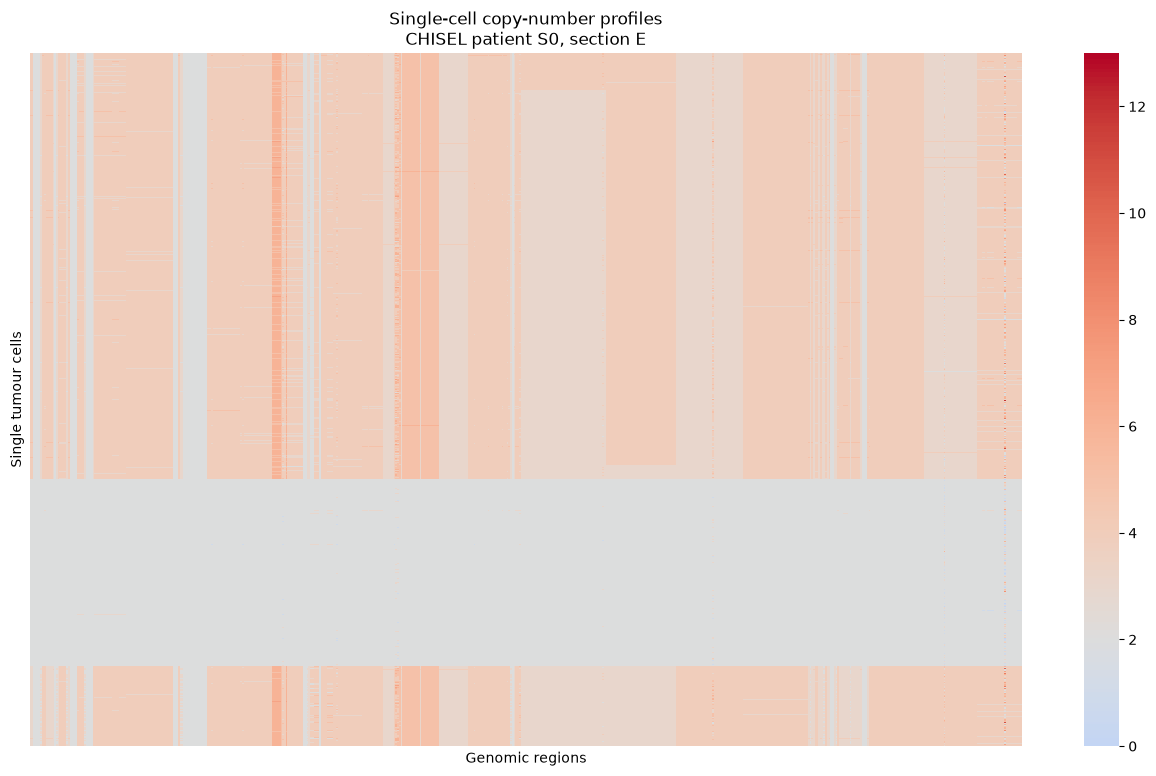

In [26]:
plt.figure(figsize=(16, 9))

sns.heatmap(
    cn_sorted,
    cmap = "coolwarm",
    center = 2,
    xticklabels = False,
    yticklabels = False
)

plt.xlabel("Genomic regions")
plt.ylabel("Single tumour cells")
plt.title(
    "Single-cell copy-number profiles\n"
    "CHISEL patient S0, section E"
)

In [27]:
chrom_order = [str(i) for i in range(1, 23)] + ["X", "Y"]

regions = (
    assigned[["CHR", "START", "END", "REGION"]]
    .drop_duplicates()
    .copy()
)

regions["CHR_STR"] = (
    regions["CHR"]
    .astype(str)
    .str.replace("chr", "", regex = False)
)

regions["CHR_ORDER"] = pd.Categorical(
    regions["CHR_STR"],
    categories = chrom_order,
    ordered = True
)

regions = regions.sort_values(
    ["CHR_ORDER", "START"]
)

region_order = regions["REGION"].tolist()

In [28]:
len(region_order)

570

In [29]:
cn_sorted = cn_matrix.loc[cell_order, region_order]

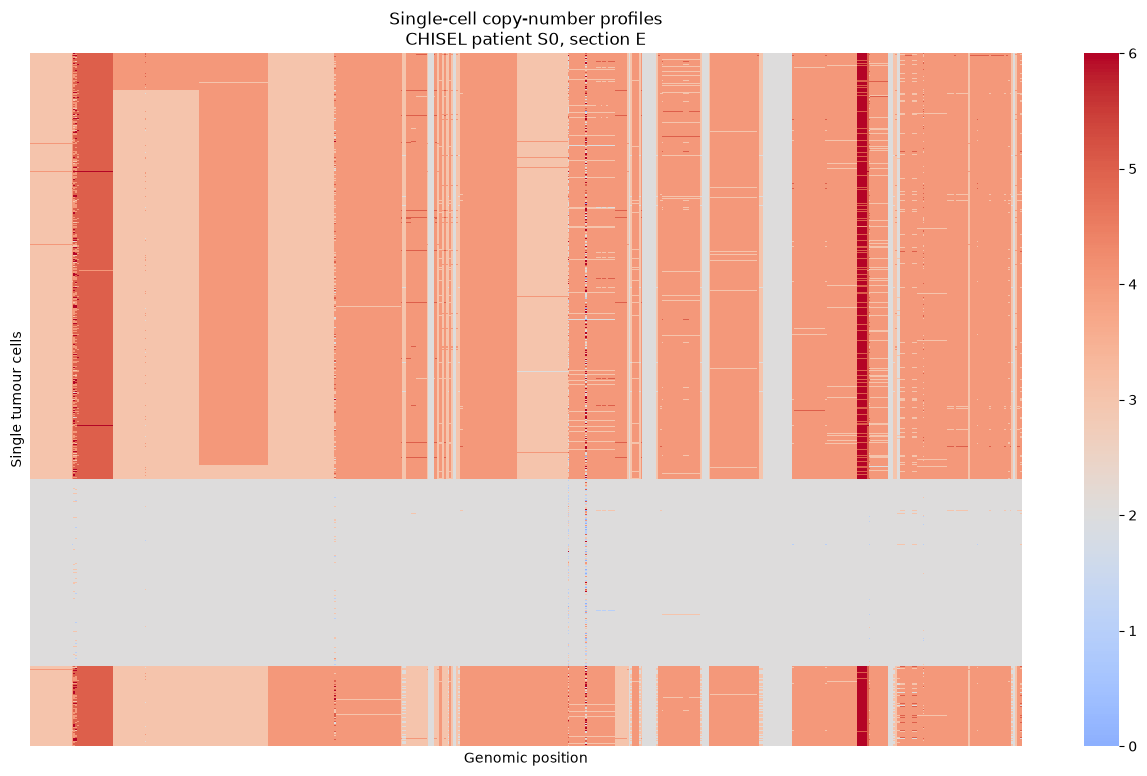

In [30]:
plt.figure(figsize = (16, 9))

sns.heatmap(
    cn_sorted,
    cmap = "coolwarm",
    center = 2,
    vmin = 0,
    vmax = 6,
    xticklabels = False,
    yticklabels = False
)

plt.xlabel("Genomic position")
plt.ylabel("Single tumour cells")

plt.title(
    "Single-cell copy-number profiles\n"
    "CHISEL patient S0, section E"
)

plt.show()

In [31]:
regions_plot = regions.reset_index(drop = True)

chrom_info = (
    regions_plot
    .groupby("CHR_STR", sort = False)
    .apply(
        lambda x: pd.Series({
            "start": x.index.min(),
            "end": x.index.max(),
            "mid": (x.index.min() + x.index.max()) / 2
        })
    )
)

chrom_info

,start,end,mid
CHR_STR,,,
1,0.0,47.0,23.5
2,48.0,96.0,72.0
3,97.0,136.0,116.5
4,137.0,175.0,156.0
5,176.0,212.0,194.0
6,213.0,247.0,230.0
7,248.0,279.0,263.5
8,280.0,309.0,294.5
9,310.0,335.0,322.5


In [32]:
clone_labels = cell_metadata.loc[cell_order, "CLONE"]

clone_counts = clone_labels.value_counts(sort = False)

clone_boundaries = clone_counts.cumsum()

clone_counts

CLONE
Clone156     58
Clone172     20
Clone199    782
Clone241     30
Clone5      390
Clone63     168
Name: count, dtype: int64

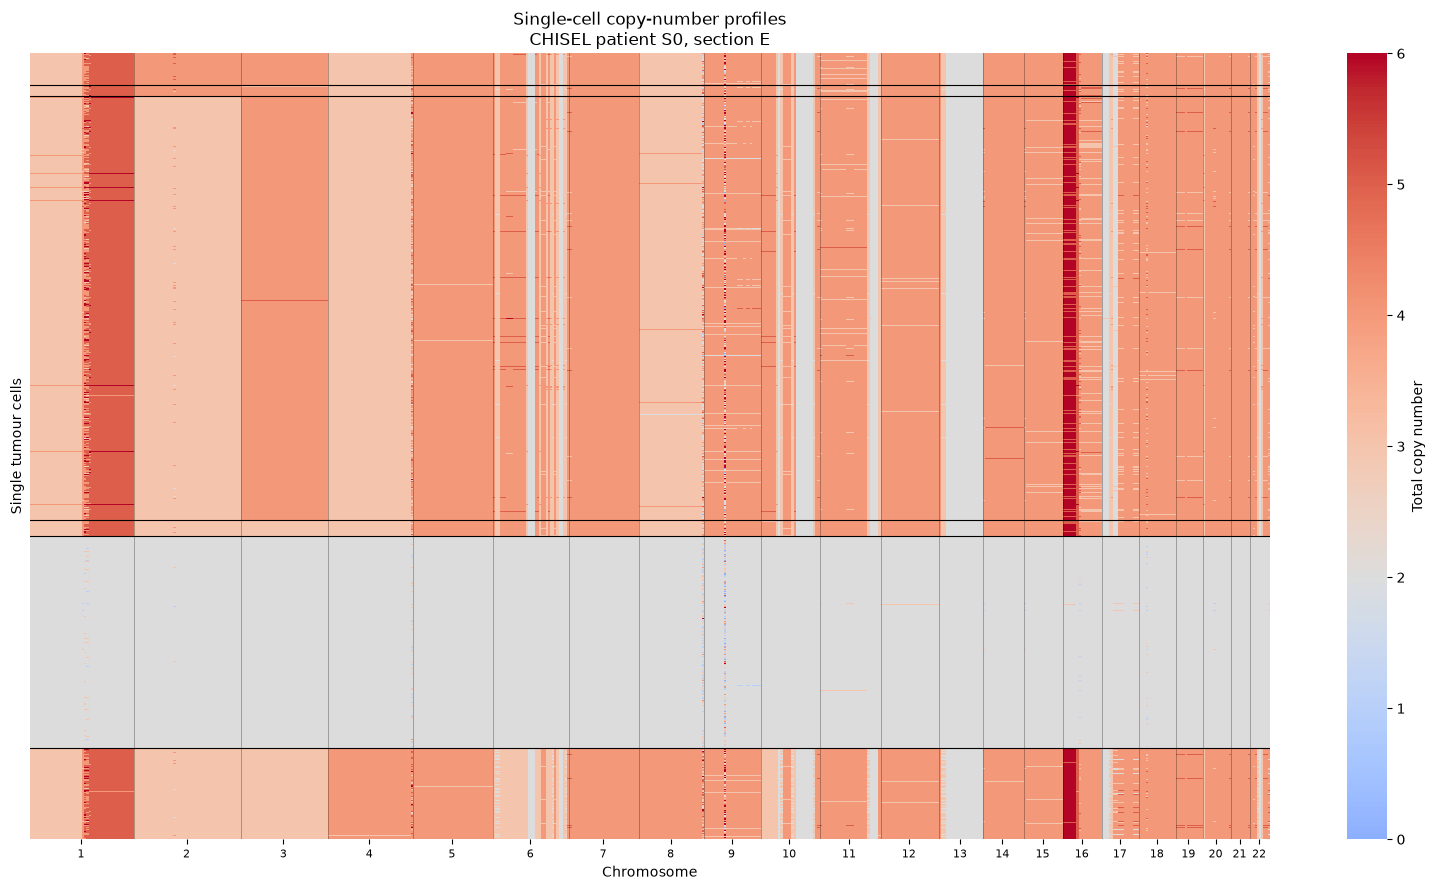

In [33]:
fig, ax = plt.subplots(figsize = (16, 9))

sns.heatmap(
    cn_sorted,
    cmap = "coolwarm",
    center = 2,
    vmin = 0,
    vmax = 6,
    xticklabels = False,
    yticklabels = False,
    ax = ax,
    cbar_kws = {"label": "Total copy number"}
)

# Chromosome boundaries
for boundary in chrom_info["end"].iloc[:-1] + 1:
    ax.axvline(boundary, color = "black", linewidth = 0.4, alpha = 0.5)

# Chromosome labels
ax.set_xticks(chrom_info["mid"])
ax.set_xticklabels(
    chrom_info.index,
    rotation = 0,
    fontsize = 8
)

# Clone boundaries
for boundary in clone_boundaries.iloc[:-1]:
    ax.axhline(boundary, color = "black", linewidth = 0.8)

ax.set_xlabel("Chromosome")
ax.set_ylabel("Single tumour cells")

ax.set_title(
    "Single-cell copy-number profiles\n"
    "CHISEL patient S0, section E"
)

plt.tight_layout()
plt.show()

In [34]:
clone_labels = cell_metadata.loc[cell_order, "CLONE"]

clone_order = clone_labels.drop_duplicates().tolist()

clone_counts = (
    clone_labels
    .value_counts()
    .reindex(clone_order)
)

clone_ends = clone_counts.cumsum()
clone_starts = clone_ends - clone_counts
clone_mids = (clone_starts + clone_ends) / 2

print(clone_counts)

CLONE
Clone156     58
Clone172     20
Clone199    782
Clone241     30
Clone5      390
Clone63     168
Name: count, dtype: int64


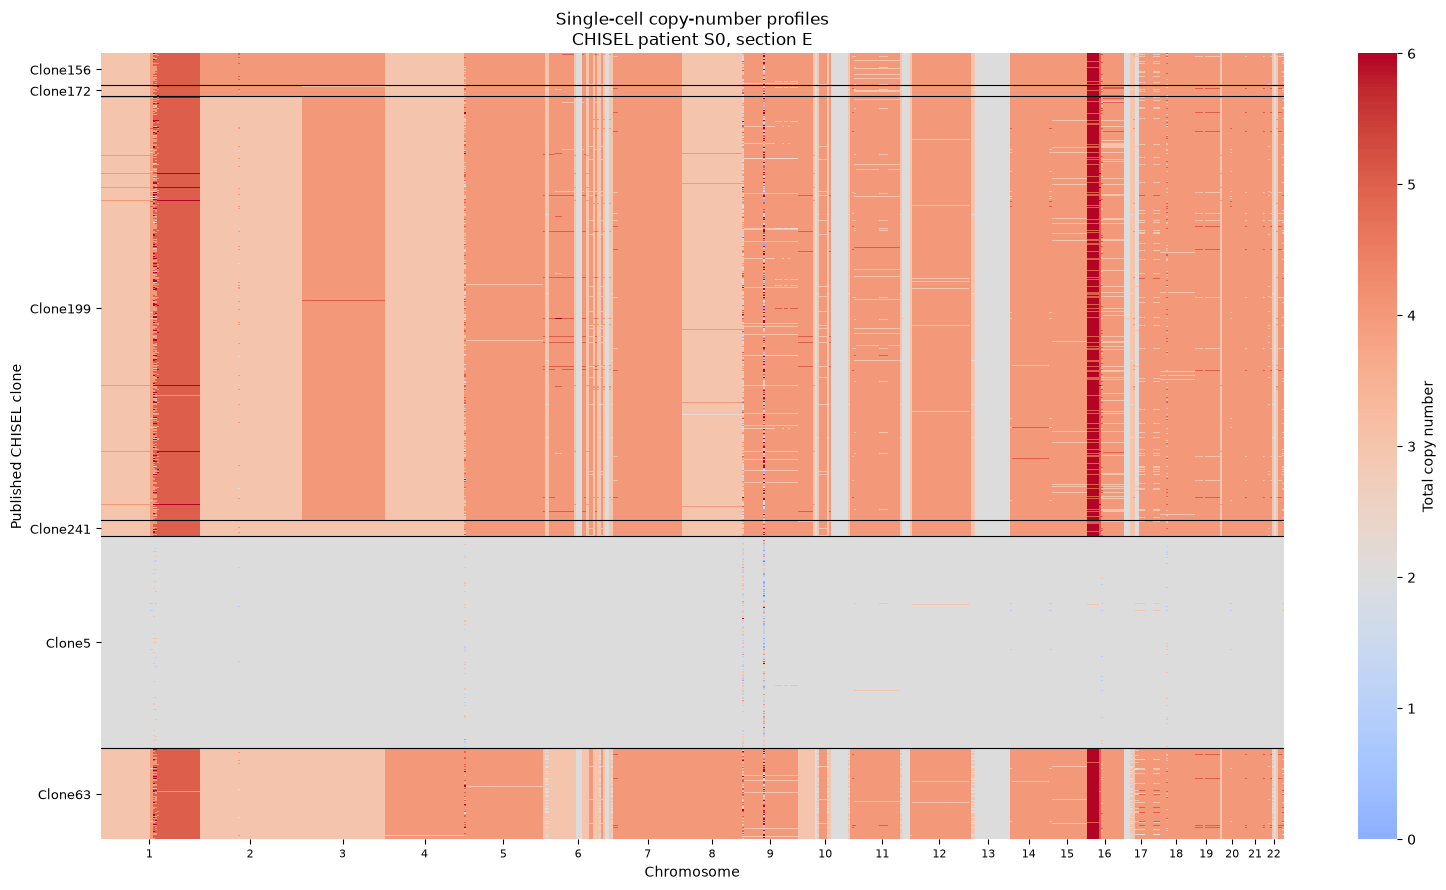

In [35]:
fig, ax = plt.subplots(figsize = (16, 9))

sns.heatmap(
    cn_sorted,
    cmap = "coolwarm",
    center = 2,
    vmin = 0,
    vmax = 6,
    xticklabels = False,
    yticklabels = False,
    ax = ax,
    cbar_kws = {"label": "Total copy number"}
)

#Chromosome boundaries
ax.set_xticks(chrom_info["mid"])
ax.set_xticklabels(
    chrom_info.index,
    rotation = 0,
    fontsize = 8
)

# Clone boundaries
for boundary in clone_ends.iloc[:-1]:
    ax.axhline(
        boundary,
        color = "black",
        linewidth = 0.8
    )

# Clone labels
ax.set_yticks(clone_mids)
ax.set_yticklabels(
    clone_order,
    rotation = 0,
    fontsize = 9
)

ax.set_xlabel("Chromosome")
ax.set_ylabel("Published CHISEL clone")

ax.set_title(
    "Single-cell copy-number profiles\n"
    "CHISEL patient S0, section E"
)

plt.tight_layout()
plt.show()

In [36]:
assigned["ALTERED_FROM_2"] = assigned["TOTAL_CN"] != 2

assigned["ALTERED_BP"] = (
    assigned["BIN_SIZE"]
    * assigned ["ALTERED_FROM_2"].astype(int)
)

In [37]:
fga = (
    assigned
    .groupby(["CELL", "CLONE"], as_index = False)
    .agg(
        altered_bp = ("ALTERED_BP", "sum"),
        total_bp = ("BIN_SIZE", "sum")
    )
)

fga["FRACTION_GENOME_ALTERED"] = (
    fga["altered_bp"] / fga["total_bp"]
)

In [38]:
fga.head()

,CELL,CLONE,altered_bp,total_bp,FRACTION_GENOME_ALTERED
0,AAACCTGCACCAAAGG,Clone199,2580637194,2790001522,0.924959
1,AAACCTGCAGGACCAA,Clone199,2585637194,2790001522,0.926751
2,AAACCTGGTAACTTCG,Clone199,2585637194,2790001522,0.926751
3,AAACCTGGTACCTAGT,Clone5,0,2790001522,0.000000
4,AAACCTGTCGATAAGA,Clone199,2595498558,2790001522,0.930286


In [39]:
fga["FRACTION_GENOME_ALTERED"].describe()

count    1448.000000
mean        0.676445
std         0.409366
min         0.000000
25%         0.003711
50%         0.926674
75%         0.926751
max         0.933843
Name: FRACTION_GENOME_ALTERED, dtype: float64

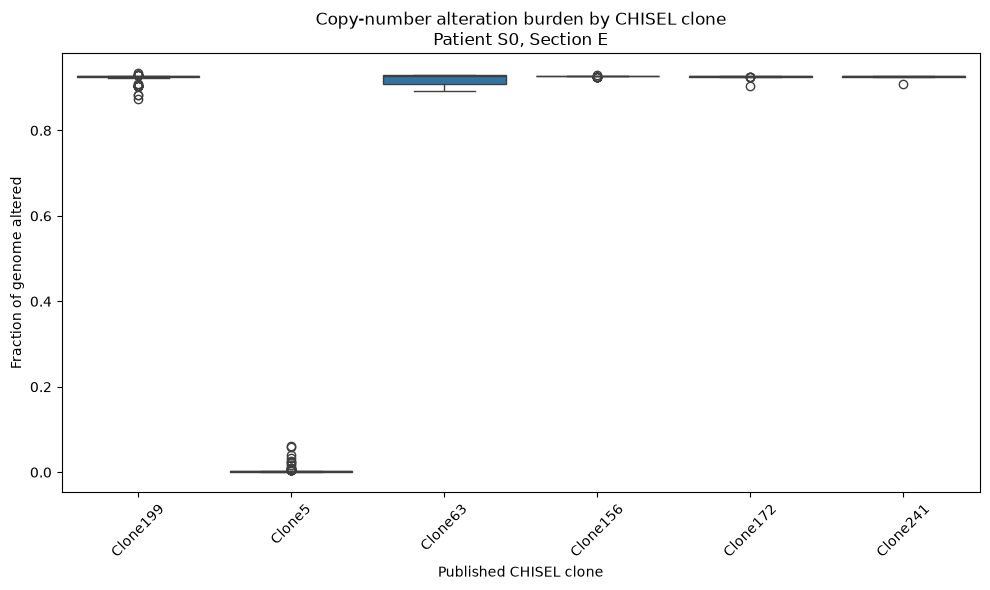

In [40]:
plt.figure(figsize = (10, 6))

sns.boxplot(
    data = fga,
    x = "CLONE",
    y = "FRACTION_GENOME_ALTERED"
)

plt.xlabel("Published CHISEL clone")
plt.ylabel("Fraction of genome altered")
plt.title(
    "Copy-number alteration burden by CHISEL clone\n"
    "Patient S0, Section E"
)

plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

In [41]:
clone_fga_summary = (
    fga
    .groupby("CLONE")["FRACTION_GENOME_ALTERED"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(3)
)

clone_fga_summary

,count,mean,median,std,min,max
CLONE,,,,,,
Clone156,58,0.926,0.927,0.001,0.925,0.930
Clone172,20,0.925,0.927,0.005,0.903,0.927
Clone199,782,0.926,0.927,0.004,0.875,0.934
Clone241,30,0.926,0.927,0.003,0.909,0.927
Clone5,390,0.002,0.002,0.005,0.000,0.060
Clone63,168,0.920,0.929,0.011,0.893,0.930


In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

pca_coords = pca.fit_transform(cn_matrix)

In [43]:
pca.explained_variance_ratio_

array([0.91911305, 0.03668943])

In [44]:
pca_df = pd.DataFrame(
    pca_coords,
    index = cn_matrix.index,
    columns = ["PC1", "PC2"]
)

In [45]:
pca_df = pca_df.join(cell_metadata)

In [46]:
pca_df.head()

,PC1,PC2,CLONE
CELL,,,
AAACCTGCACCAAAGG,11.481743,-1.588681,Clone199
AAACCTGCAGGACCAA,12.110125,-1.665192,Clone199
AAACCTGGTAACTTCG,12.041299,-1.645325,Clone199
AAACCTGGTACCTAGT,-30.770691,-0.109758,Clone5
AAACCTGTCGATAAGA,11.756890,-1.628562,Clone199


Text(0.5, 0, 'PC1 (91.9 % variance)')

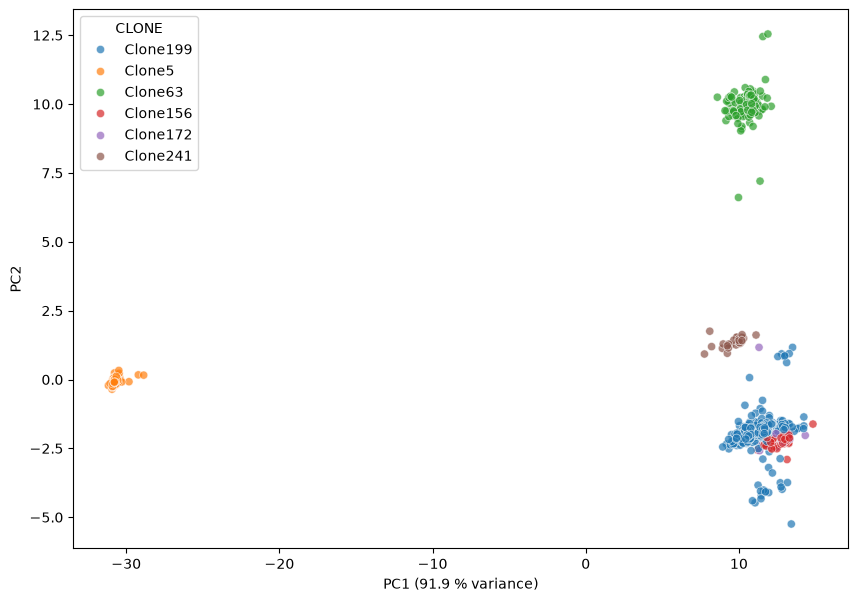

In [47]:
plt.figure(figsize = (10, 7))

sns.scatterplot(
    data = pca_df,
    x = "PC1",
    y = "PC2",
    hue = "CLONE",
    s = 35,
    alpha = 0.7
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f} % variance)"
)

In [48]:
pca.explained_variance_ratio_

array([0.91911305, 0.03668943])

In [49]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    cn_matrix.values,
    method = "ward"
)

In [50]:
hc_clusters = fcluster(
    Z,
    t = 6,
    criterion = "maxclust"
)

In [51]:
pca_df["HC_CLUSTER"] = hc_clusters

In [52]:
comparison = pd.crosstab(
    pca_df["CLONE"],
    pca_df["HC_CLUSTER"]
)

comparison

HC_CLUSTER,1,2,3,4,5,6
CLONE,,,,,,
Clone156,0,0,58,0,0,0
Clone172,0,0,20,0,0,0
Clone199,0,0,0,154,0,628
Clone241,0,0,0,1,29,0
Clone5,390,0,0,0,0,0
Clone63,0,168,0,0,0,0


In [53]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(
    pca_df["CLONE"],
    pca_df["HC_CLUSTER"]
)

print("Adjusted Rand Index:", round(ari, 3))

Adjusted Rand Index: 0.792


In [54]:
cn_a_matrix = assigned.pivot(
    index = "CELL",
    columns = "REGION",
    values = "CN_A"
)

cn_b_matrix = assigned.pivot(
    index = "CELL",
    columns = "REGION",
    values = "CN_B"
)

In [55]:
cn_a_matrix = cn_a_matrix.loc[
    cn_matrix.index,
    region_order
]

cn_b_matrix = cn_b_matrix.loc[
    cn_matrix.index,
    region_order
]

In [56]:
cn_a_matrix.columns = [
    f"A_{region}" for region in cn_a_matrix.columns
]

cn_b_matrix.columns = [
    f"B_{region}" for region in cn_b_matrix.columns
]

In [57]:
allele_matrix = pd.concat(
    [cn_a_matrix, cn_b_matrix],
    axis = 1
)

In [58]:
allele_matrix.shape

(1448, 1140)

In [59]:
allele_matrix.isna().sum().sum()

np.int64(0)

In [60]:
allele_pca = PCA(n_components = 2)

allele_coords = allele_pca.fit_transform(
    allele_matrix
)

In [61]:
allele_pca.explained_variance_ratio_

array([0.75933959, 0.08308672])

In [62]:
allele_pca_df = pd.DataFrame(
    allele_coords,
    index = allele_matrix.index,
    columns = ["PC1", "PC2"]
)

allele_pca_df = allele_pca_df.join(
    cell_metadata
)

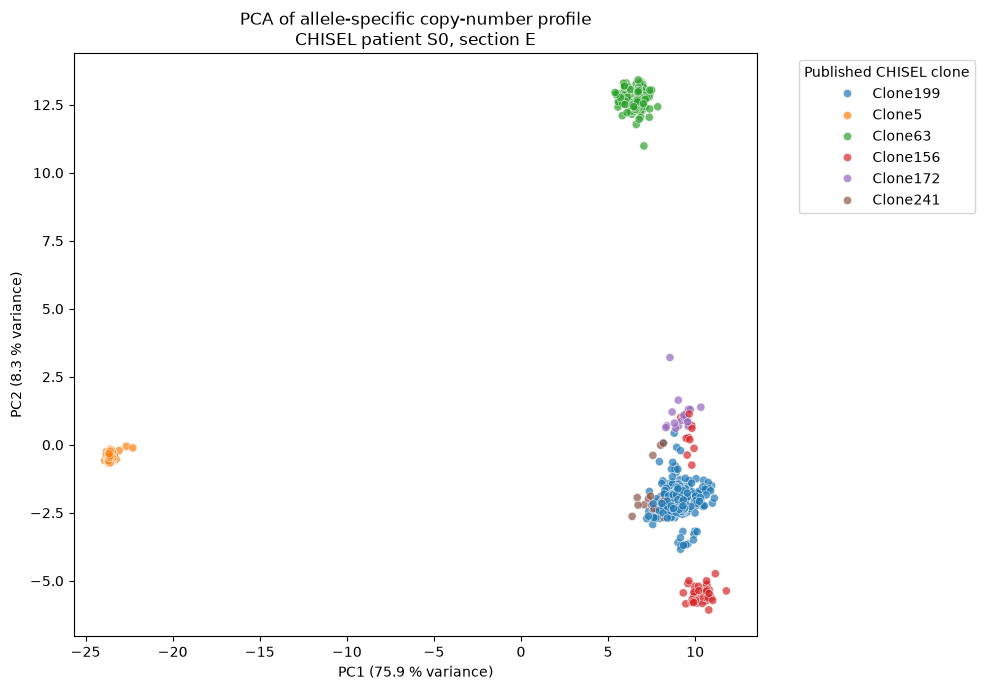

In [63]:
plt.figure(figsize = (10, 7))

sns.scatterplot(
    data = allele_pca_df,
    x = "PC1",
    y = "PC2",
    hue = "CLONE",
    s = 35,
    alpha = 0.7
)

plt.xlabel(
    f"PC1 ({allele_pca.explained_variance_ratio_[0] * 100:.1f} % variance)"
)

plt.ylabel(
    f"PC2 ({allele_pca.explained_variance_ratio_[1] * 100:.1f} % variance)"
)

plt.title(
    "PCA of allele-specific copy-number profile\n"
    "CHISEL patient S0, section E"
)

plt.legend(
    title = "Published CHISEL clone",
    bbox_to_anchor = (1.05, 1),
    loc = "upper left"
)

plt.tight_layout()
plt.show()

In [64]:
Z_allele = linkage(
    allele_matrix.values,
    method = "ward"
)

allele_hc_clusters = fcluster(
    Z_allele,
    t = 6,
    criterion = "maxclust"
)

In [65]:
allele_pca_df["HC_CLUSTER"] = allele_hc_clusters

In [66]:
allele_comparison = pd.crosstab(
    allele_pca_df["CLONE"],
    allele_pca_df["HC_CLUSTER"]
)

allele_comparison

HC_CLUSTER,1,2,3,4,5,6
CLONE,,,,,,
Clone156,0,0,48,0,0,10
Clone172,0,0,0,0,0,20
Clone199,0,0,0,659,123,0
Clone241,0,0,0,27,3,0
Clone5,390,0,0,0,0,0
Clone63,0,168,0,0,0,0


In [67]:
allele_ari = adjusted_rand_score(
    allele_pca_df["CLONE"],
    allele_pca_df["HC_CLUSTER"]
)

print("Allele-specific ARI:", round(allele_ari, 3))
print("Total-CN ARI:", round(ari, 3))

Allele-specific ARI: 0.791
Total-CN ARI: 0.792


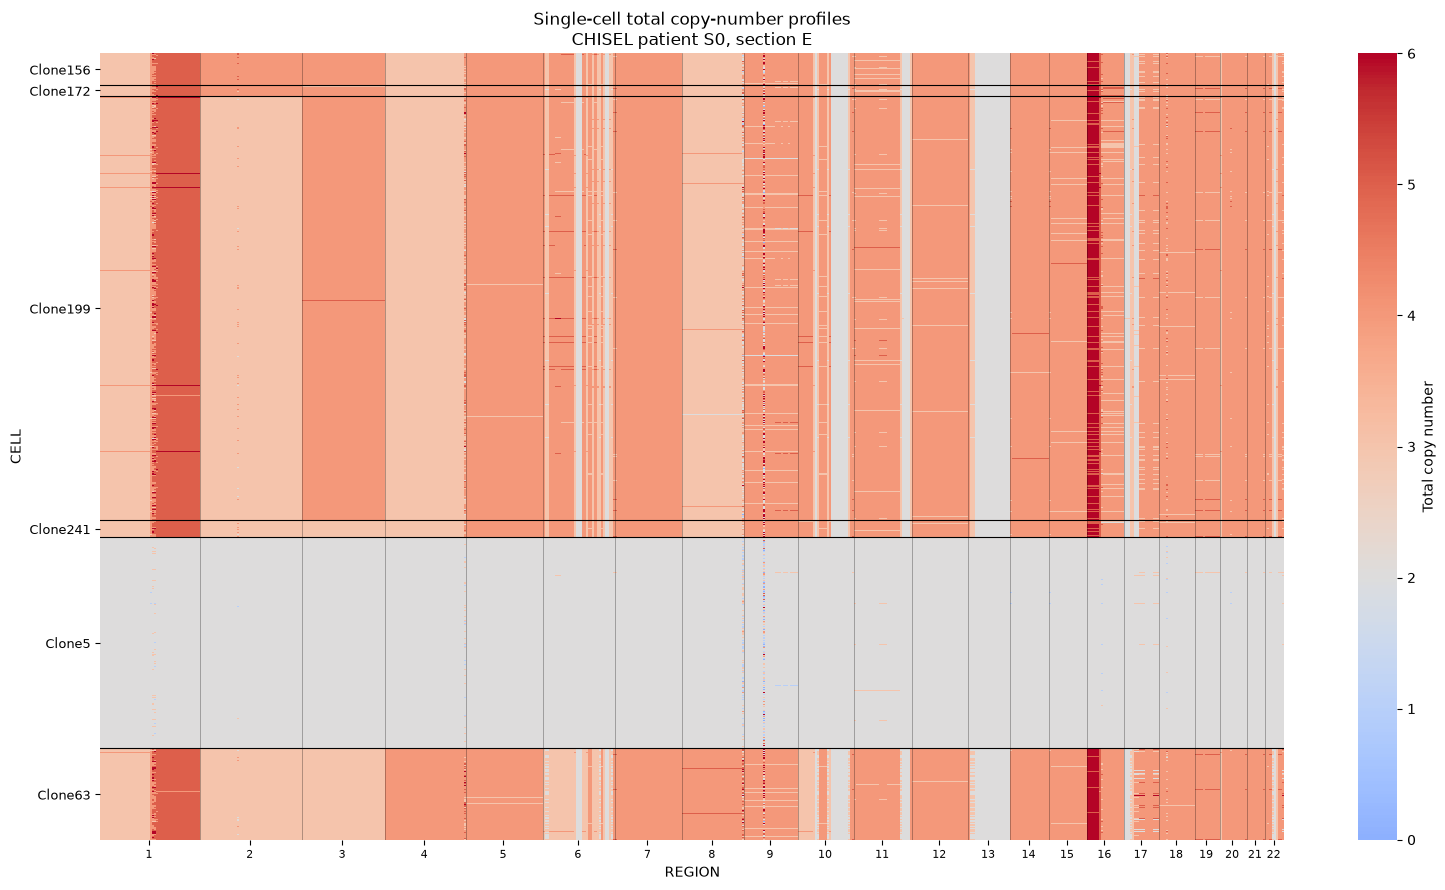

In [68]:
fig, ax = plt.subplots(figsize = (16, 9))

sns.heatmap(
    cn_sorted,
    cmap = "coolwarm",
    center = 2,
    vmin = 0,
    vmax = 6,
    xticklabels = False,
    yticklabels = False,
    ax = ax,
    cbar_kws = {"label": "Total copy number"}
)

# Chromosome boundaries
for boundary in chrom_info["end"].iloc[:-1] + 1:
    ax.axvline(
        boundary,
        color = "black",
        linewidth = 0.4,
        alpha = 0.5
    )

# Chromosome labels
ax.set_xticks(chrom_info["mid"])
ax.set_xticklabels(
    chrom_info.index,
    rotation = 0,
    fontsize = 8
)

# Clone boundaries
for boundary in clone_ends.iloc[:-1]:
    ax.axhline(
        boundary,
        color = "black",
        linewidth = 0.8
    )

# Clone labels
ax.set_yticks(clone_mids)
ax.set_yticklabels(
    clone_order,
    rotation = 0,
    fontsize = 9
)

ax.set_title(
    "Single-cell total copy-number profiles\n"
    "CHISEL patient S0, section E"
)

plt.tight_layout()

plt.savefig(
    "figures/figure1_copy_number_heatmap.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

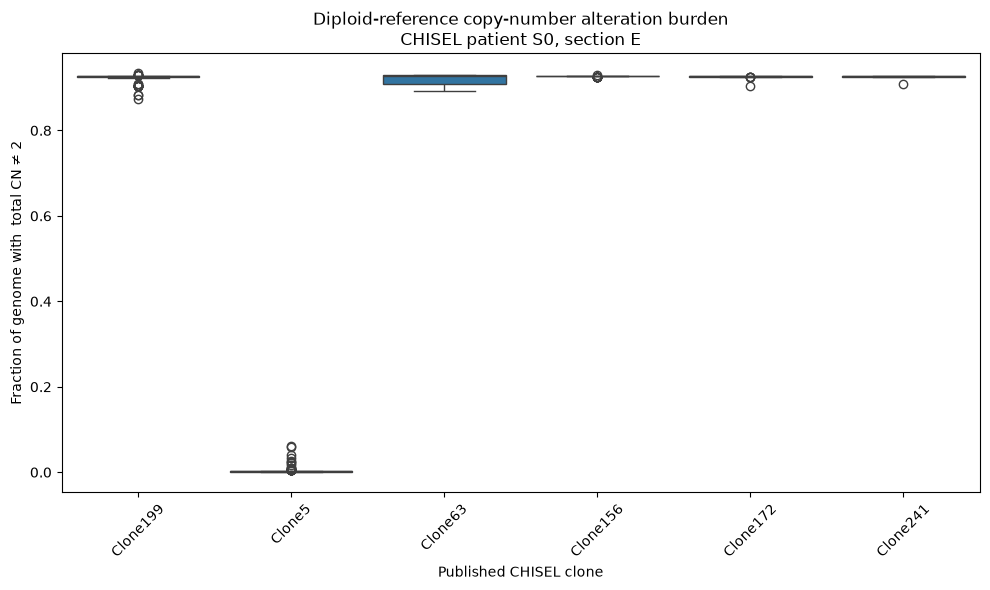

In [69]:
plt.figure(figsize = (10, 6))

sns.boxplot(
    data = fga,
    x = "CLONE",
    y = "FRACTION_GENOME_ALTERED"
)

plt.xlabel("Published CHISEL clone")
plt.ylabel("Fraction of genome with  total CN ≠ 2")

plt.title(
    "Diploid-reference copy-number alteration burden\n"
    "CHISEL patient S0, section E"
)

plt.xticks(rotation = 45)

plt.tight_layout()

plt.savefig(
    "figures/figure2_diploid_reference_burden.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

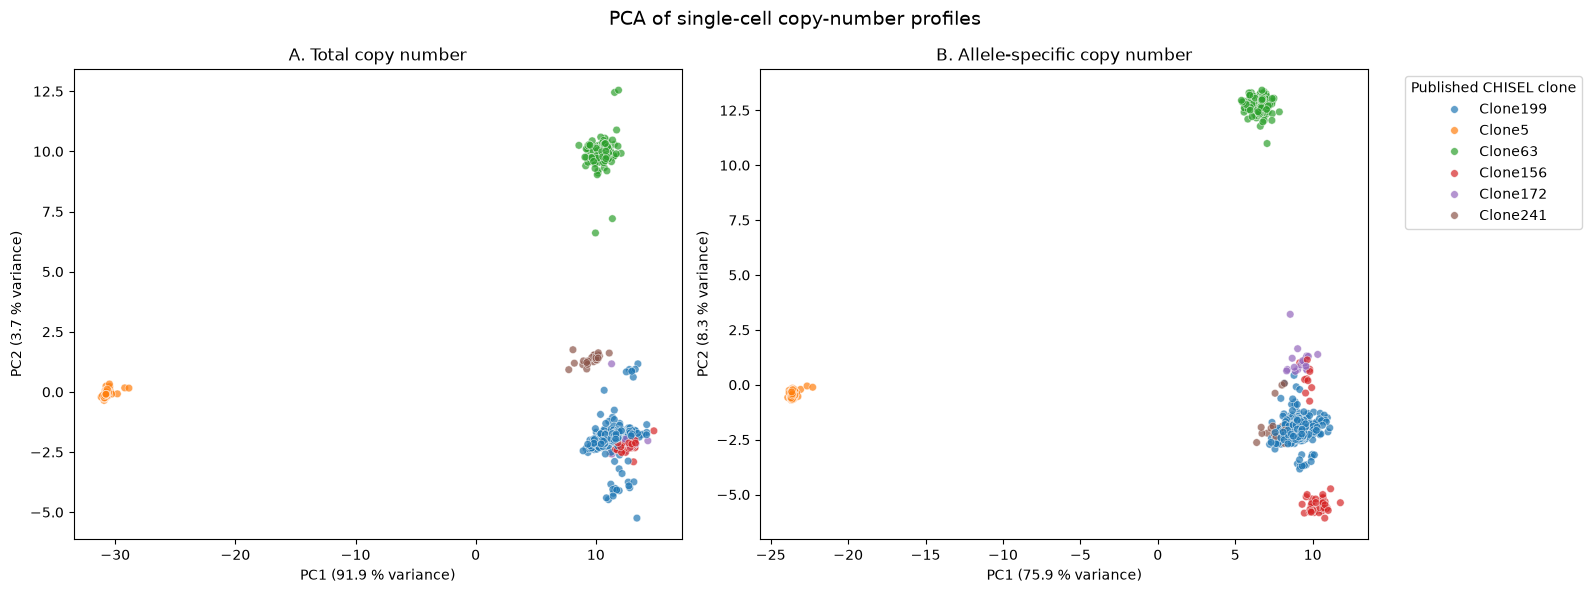

In [70]:
fig, axes = plt.subplots(
    1,
    2,
    figsize = (16, 6)
)

# Total copy-number PCA
sns.scatterplot(
    data = pca_df,
    x = "PC1",
    y = "PC2",
    hue = "CLONE",
    s = 30,
    alpha = 0.7,
    ax = axes[0],
    legend = False
)

axes[0].set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f} % variance)"
)

axes[0].set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f} % variance)"
)

axes[0].set_title("A. Total copy number")

# Allele-specific PCA
sns.scatterplot(
    data = allele_pca_df,
    x = "PC1",
    y = "PC2",
    hue = "CLONE",
    s = 30,
    alpha = 0.7,
    ax = axes[1]
)

axes[1].set_xlabel(
    f"PC1 ({allele_pca.explained_variance_ratio_[0] * 100:.1f} % variance)"
)

axes[1].set_ylabel(
    f"PC2 ({allele_pca.explained_variance_ratio_[1] * 100:.1f} % variance)"
)

axes[1].set_title("B. Allele-specific copy number")

axes[1].legend(
    title = "Published CHISEL clone",
    bbox_to_anchor = (1.05, 1),
    loc = "upper left"
)

fig.suptitle(
    "PCA of single-cell copy-number profiles",
    fontsize = 14
)

plt.tight_layout()

plt.savefig(
    "figures/figure3_pca_comparison.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

In [73]:
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster

rng = np.random.default_rng(42)

n_repeats = 100
sample_fraction = 0.80

total_ari_scores = []
allele_ari_scores = []

for i in range(n_repeats):

    sampled_cells = []

    for clone, group in cell_metadata.groupby("CLONE"):

        cells = group.index.to_numpy()

        n_sample = int(len(cells) * sample_fraction)

        selected = rng.choice(
            cells,
            size = n_sample,
            replace = False
        )

        sampled_cells.extend(selected)

    sampled_cells = np.array(sampled_cells)

    true_labels = cell_metadata.loc[
        sampled_cells,
        "CLONE"
    ]

    X_total = cn_matrix.loc[sampled_cells]

    Z_total = linkage(
        X_total.values,
        method = "ward"
    )

    clusters_total = fcluster(
        Z_total,
        t = 6,
        criterion = "maxclust"
    )

    total_ari_scores.append(
        adjusted_rand_score(
            true_labels,
            clusters_total
        )
    )

    X_allele = allele_matrix.loc[sampled_cells]

    Z_allele_sample = linkage(
        X_allele.values,
        method = "ward"
    )

    clusters_allele = fcluster(
        Z_allele_sample,
        t = 6,
        criterion = "maxclust"
    )

    allele_ari_scores.append(
        adjusted_rand_score(
            true_labels,
            clusters_allele
        )
    )

In [75]:
total_ari_scores = np.array(total_ari_scores)
allele_ari_scores = np.array(allele_ari_scores)

print("TOTAL COPY NUMBER")
print("Median ARI:", np.median(total_ari_scores))
print(
    "95% resampling interval:",
    np.percentile(total_ari_scores, [2.5, 97.5])
)

print()

print("ALLELE-SPECIFIC COPY NUMBER")
print("Median ARI:", np.median(allele_ari_scores))
print(
    "95% resampling interval:",
    np.percentile(allele_ari_scores, [2.5, 97.5])
)

TOTAL COPY NUMBER
Median ARI: 0.6759437597938713
95% resampling interval: [0.56947769 0.81623073]

ALLELE-SPECIFIC COPY NUMBER
Median ARI: 0.7140610332265338
95% resampling interval: [0.63977255 0.8162038 ]


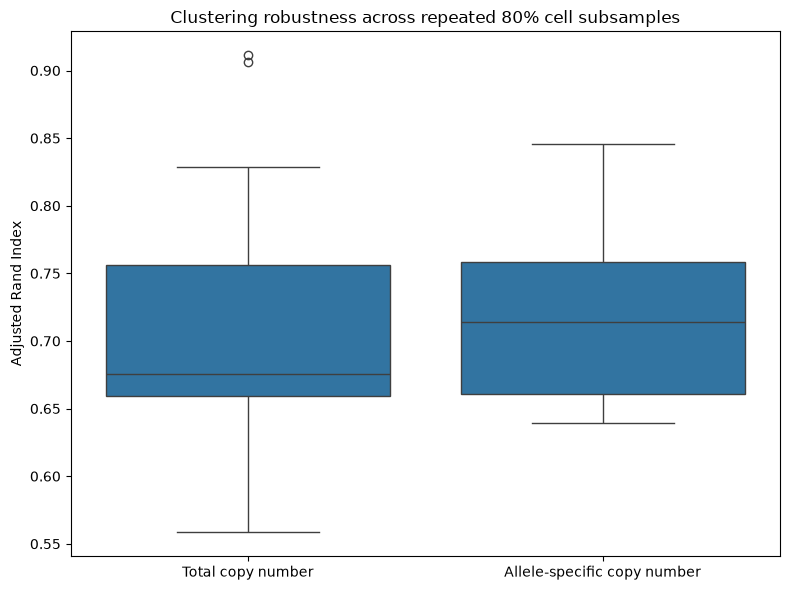

In [77]:
robustness_df = pd.DataFrame({
    "Total copy number": total_ari_scores,
    "Allele-specific copy number": allele_ari_scores
})

robustness_long = robustness_df.melt(
    var_name = "Representation",
    value_name = "ARI"
)

plt.figure(figsize = (8, 6))

sns.boxplot(
    data = robustness_long,
    x = "Representation",
    y = "ARI"
)

plt.ylabel("Adjusted Rand Index")
plt.xlabel("")

plt.title(
    "Clustering robustness across repeated 80% cell subsamples"
)

plt.tight_layout()

plt.savefig(
    "figures/figure4_clustering_robustness.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

In [78]:
ari_difference = allele_ari_scores - total_ari_scores

print(
    "Median allele-specific minus total-CN ARI:",
    np.median(ari_difference)
)

print(
    "95% resampling interval for difference:",
    np.percentile(ari_difference, [2.5, 97.5])
)

print(
    "Fraction of subsamples where allele-specific ARI was higher:",
    np.mean(ari_difference > 0)
)

Median allele-specific minus total-CN ARI: 0.007603636112599121
95% resampling interval for difference: [-0.1285756   0.18013548]
Fraction of subsamples where allele-specific ARI was higher: 0.53


## Summary of main results

- 2,075 cells were present in section E.
- 1,448 cells had one of six published CHISEL clone assignments.
- Total-copy-number PCA explained 91.9% and 3.7% of variance in PC1 and PC2, respectively.
- Hierarchical clustering of total copy number showed substantial agreement with the published clone labels (ARI = 0.792).
- Clone5 and Clone63 were recovered cleanly by simple total-copy-number clustering.
- Clone156 and Clone172 were merged by total-copy-number clustering.
- Allele-specific PCA revealed additional separation between Clone156 and Clone172.
- On the complete dataset, allele-specific Ward clustering showed almost identical agreement with CHISEL to total-copy-number clustering (ARI = 0.791 vs 0.792).
- Across 100 stratified 80% cell subsamples, median ARI was 0.676 for total copy number and 0.714 for allele-specific copy number.
- The paired median difference in ARI was only 0.008, with a 95% resampling interval of -0.129 to 0.180. Allele-specific clustering achieved a higher ARI in 53% of subsamples.

## Conclusion

Simple analysis of CHISEL-derived single-cell copy-number profiles recovered a substantial proportion of the published tumour clone structure.

Genome-wide total copy number was sufficient to distinguish several major populations, particularly Clone5 and Clone63. Total-copy-number hierarchical clustering showed substantial agreement with the published CHISEL assignments (adjusted Rand index = 0.792).

However, total copy number did not reproduce all published clone distinctions. In particular, Clone156 and Clone172 were merged by simple hierarchical clustering. Preserving allele-specific copy numbers revealed additional separation between these populations in PCA. This demonstrates that collapsing haplotype-specific states into total copy number can discard informative genomic variation.

Despite this additional structure, allele-specific Ward clustering did not consistently improve recovery of the published CHISEL clones. On the complete dataset, allele-specific and total-copy-number clustering produced almost identical ARI values (0.791 and 0.792, respectively). Across repeated stratified 80% subsamples, allele-specific clustering showed a modestly higher median ARI. However, the paired median difference was only 0.008 and the 95% resampling interval for the difference spanned zero (-0.129 to 0.180). Allele-specific clustering achieved a higher ARI in 53% of subsamples.

Together, these results suggest that allele-specific information reveals additional genomic structure. However, this does not translate into a consistent improvement in clone recovery under simple Ward hierarchical clustering. This is consistent with CHISEL using a more specialised clone-inference procedure than simple Euclidean hierarchical clustering.

## Limitations

This analysis uses copy-number states already inferred by CHISEL rather than raw single-cell DNA sequencing reads. It therefore evaluates structure within CHISEL-derived outputs rather than independently validating CHISEL's copy-number inference.

The analysis was restricted to patient S0, tumour section E. The results should not be interpreted as a general assessment of CHISEL performance.

Cells from the same tumour section are not independent biological replicates. The resampling analysis therefore assesses within-dataset clustering stability rather than population-level uncertainty.

The reported 95% resampling intervals describe the distribution of results across repeated 80% cell subsamples and should not be interpreted as conventional population-level confidence intervals.

The fraction of genome with total copy number different from two uses a diploid reference. This metric can be misleading for cells with elevated baseline ploidy or whole-genome duplication.

PCA provides a linear representation of genomic variation and does not explicitly model tumour evolutionary relationships.

Ward hierarchical clustering uses Euclidean distance and is a simple comparison method. It does not reproduce the specialised clone inference procedure used by CHISEL.